In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from src.features.build_features import (
    drop_features,
    add_new_features,
    make_dummies,
    postprocess_drop_features,
)
from pathlib import Path

In [2]:
project_dir = Path(Path.cwd()).parents[0]
df = pd.read_csv(
    project_dir / "data" / "raw" / "IBM_HR_attr.csv", index_col="Unnamed: 0"
)
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [3]:
df = drop_features(df)
df = add_new_features(df)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1470 entries, 0 to 1469
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   int64  
 1   Attrition                 1470 non-null   object 
 2   BusinessTravel            1470 non-null   object 
 3   DailyRate                 1470 non-null   int64  
 4   Department                1470 non-null   object 
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1470 non-null   object 
 8   EnvironmentSatisfaction   1470 non-null   int64  
 9   Gender                    1470 non-null   object 
 10  HourlyRate                1470 non-null   int64  
 11  JobInvolvement            1470 non-null   int64  
 12  JobLevel                  1470 non-null   int64  
 13  JobRole                   1470 non-null   object 
 14  JobSatisfacti

In [4]:
columns_name = list(df.columns)

del_name = [21, 17, 15, 11, 7, 4, 2, 1]
columns_name_numeric = list(df.columns)
for i in del_name:
    del columns_name_numeric[i]

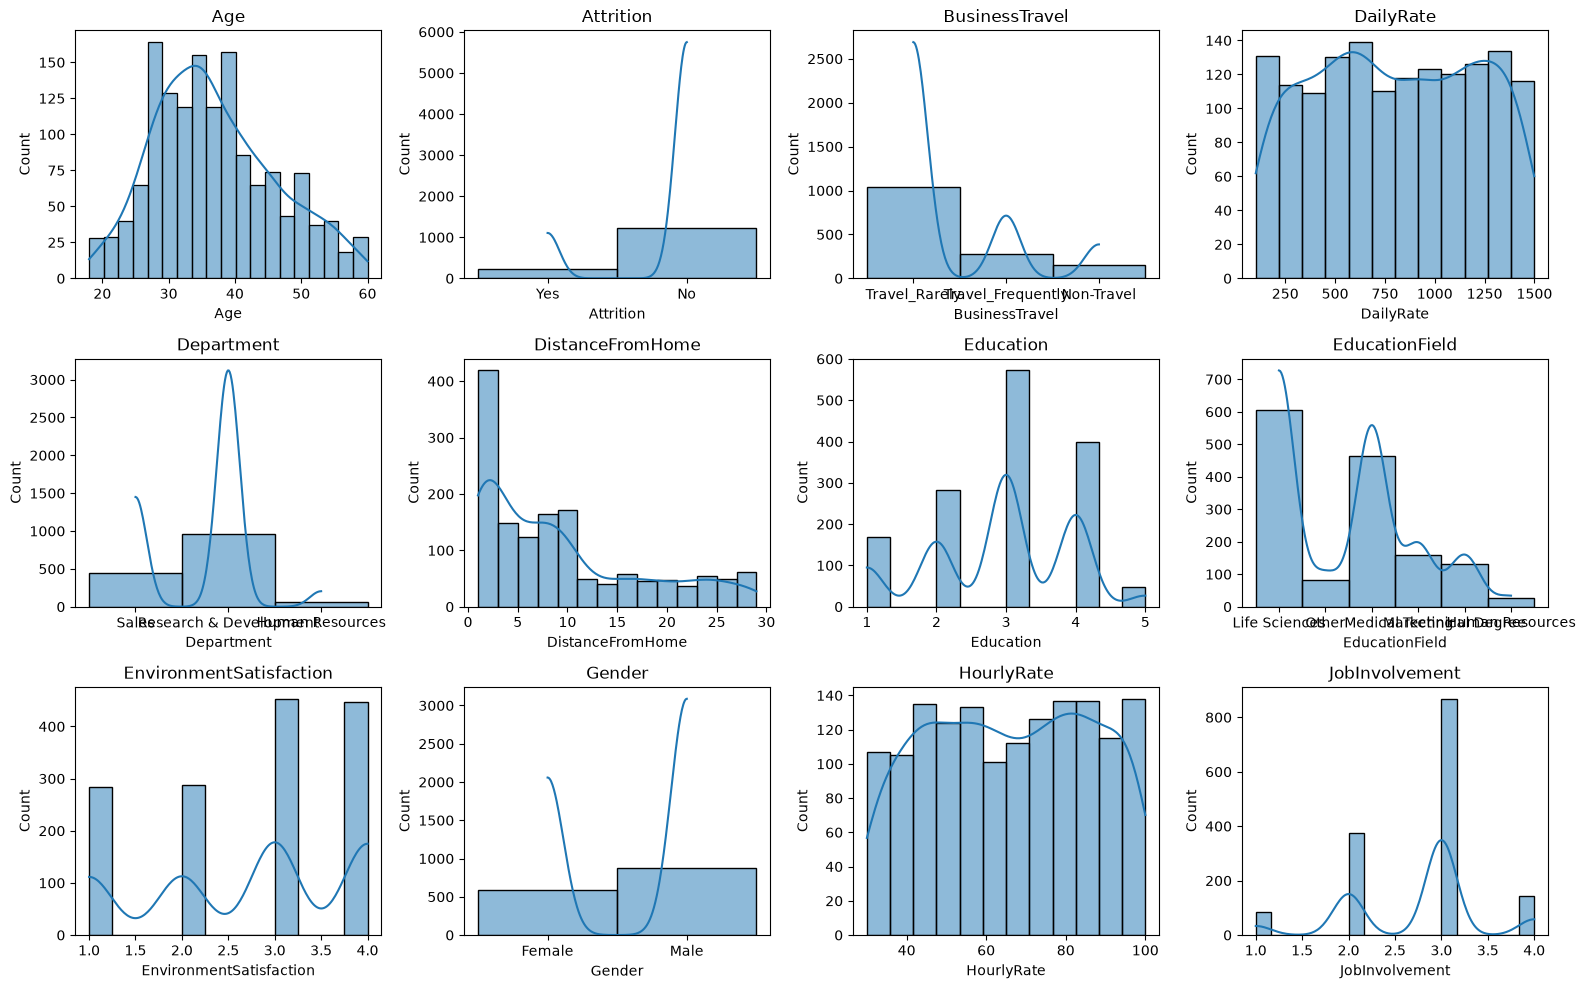

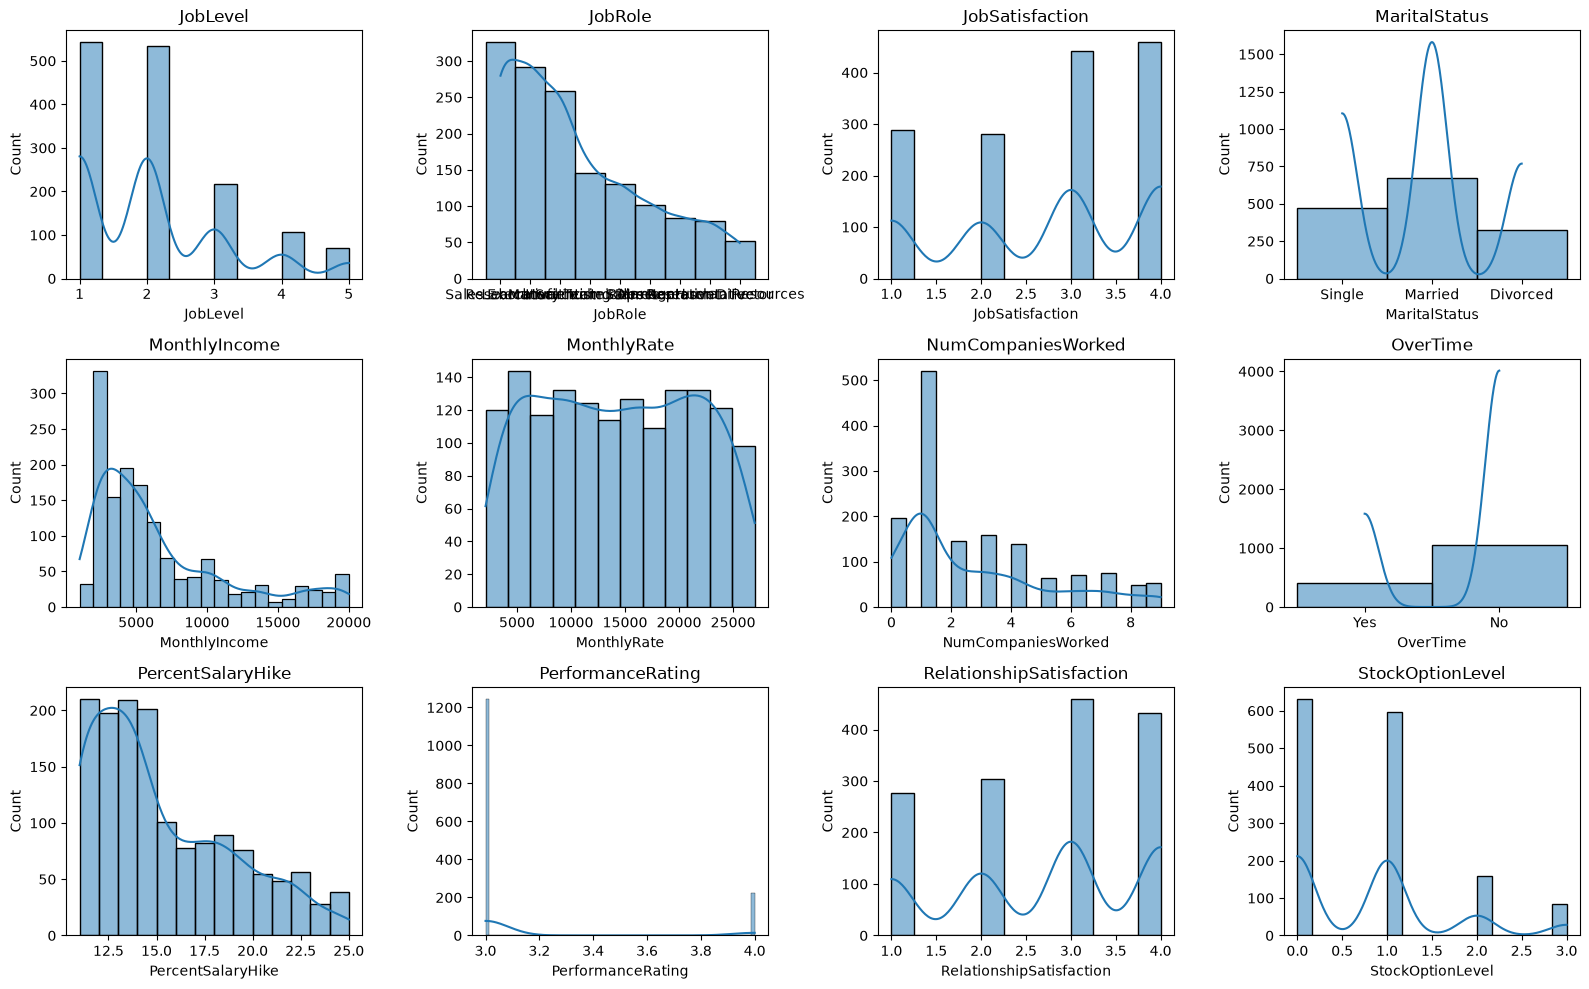

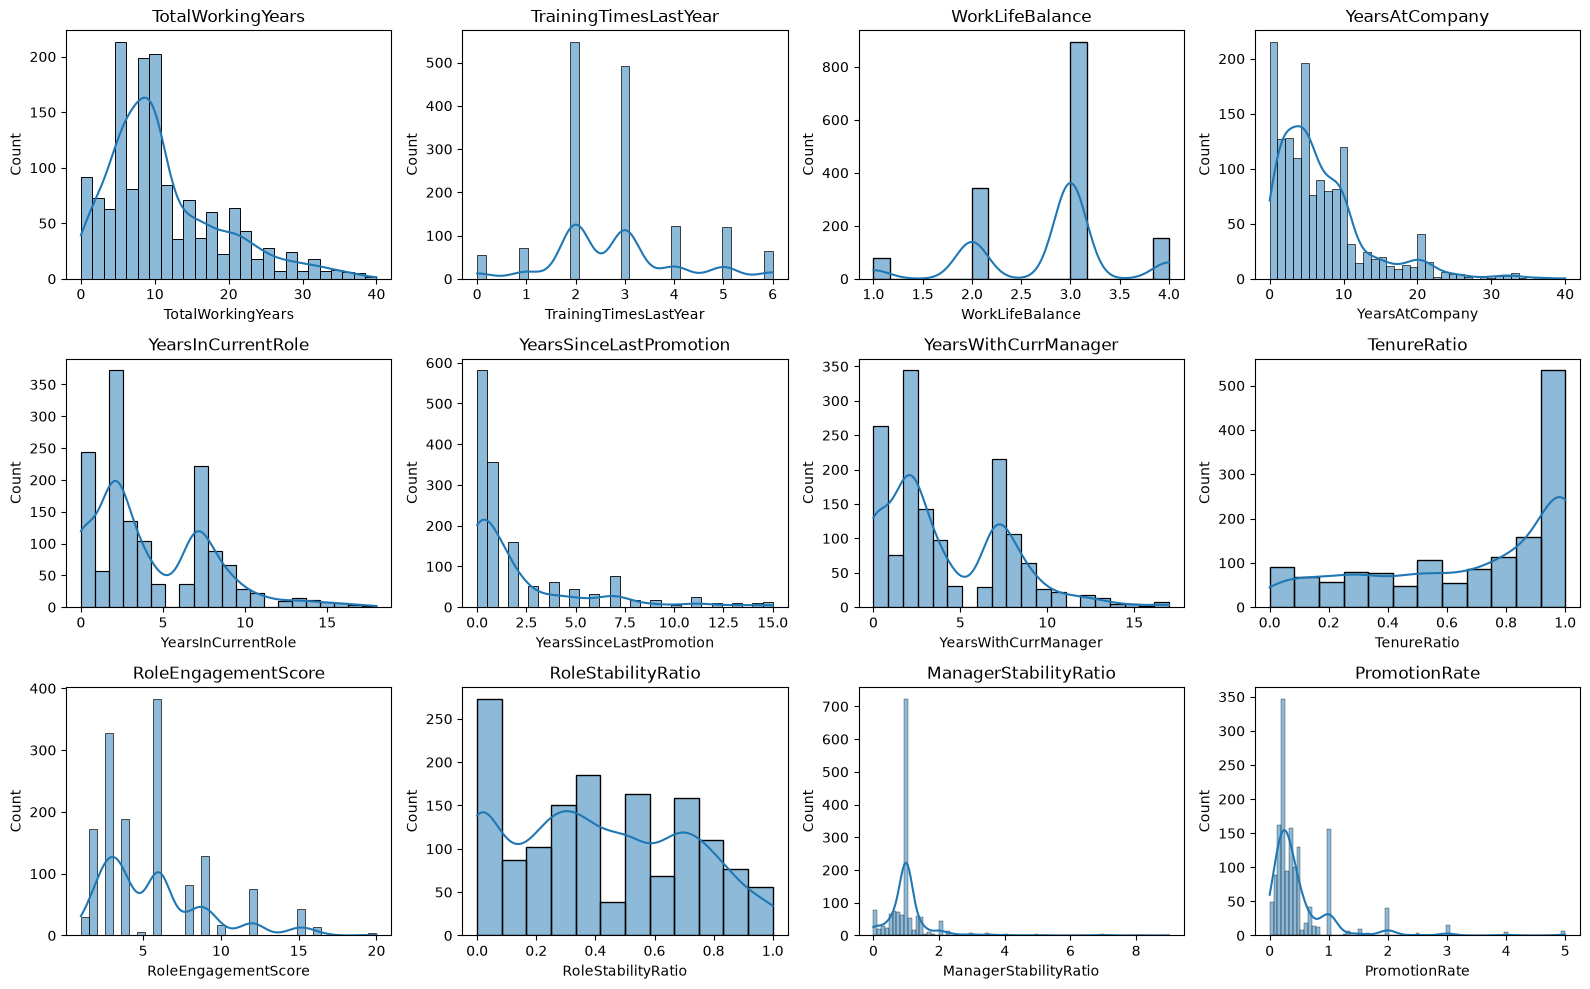

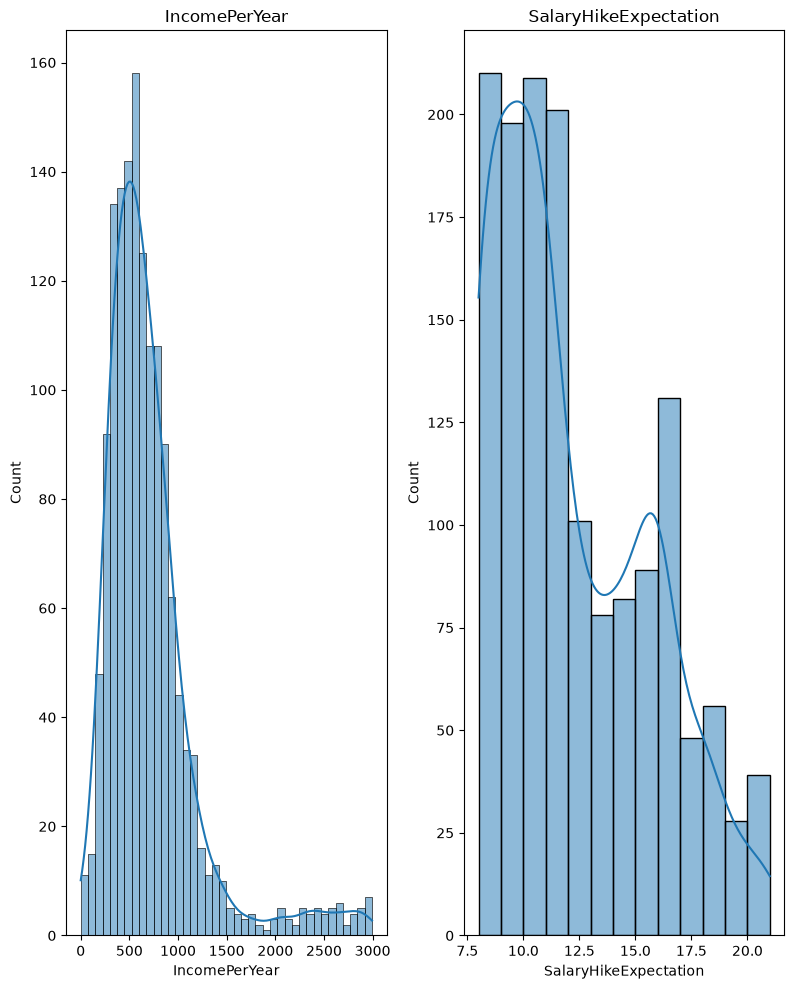

In [5]:
batch_size = 12

for batch_start in range(0, len(columns_name), batch_size):
    batch_end = min(batch_start + batch_size, len(columns_name))
    batch_columns = columns_name[batch_start:batch_end]

    rows = (len(batch_columns) + 3) // 4
    fig, axes = plt.subplots(nrows=rows, ncols=4, figsize=(16, 10))
    axes = axes.flatten()

    for i, column in enumerate(batch_columns):
        sns.histplot(df[column], ax=axes[i], kde=True)
        axes[i].set_title(column)

    for j in range(len(batch_columns), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [ ]:
for batch_start in range(0, len(columns_name_numeric), batch_size):
    batch_end = min(batch_start + batch_size, len(columns_name_numeric))
    batch_columns = columns_name_numeric[batch_start:batch_end]

    rows = (len(batch_columns) + 3) // 4
    fig, axes = plt.subplots(nrows=rows, ncols=4, figsize=(16, 10))
    axes = axes.flatten()

    for i, column in enumerate(batch_columns):
        sns.boxplot(y=df[column], ax=axes[i])
        axes[i].set_title(column)

    for j in range(len(batch_columns), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [ ]:
features = df.columns.tolist()
normalize_features = [
    i
    for i in features
    if i
    not in [
        "Attrition",
        "Gender",
        "OverTime",
        "BusinessTravel",
        "Department",
        "EducationField",
        "JobRole",
        "MaritalStatus",
    ]
]

print(normalize_features)

In [ ]:
new_df = make_dummies(df)

In [ ]:
sns.set(rc={"figure.figsize": (30, 20)})
correlation_matrix = new_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")

In [ ]:
X = new_df.copy()
X = X.drop(["Attrition_Yes"], axis=1)
y = new_df["Attrition_Yes"]

In [ ]:
majority = new_df[new_df["Attrition_Yes"] == 0]
minority = new_df[new_df["Attrition_Yes"] == 1]
print(len(minority) / len(majority))

features = ["0", "1"]  # метки для столбцов
counts = [
    len(majority),
    len(minority),
]  # количество наблюдений в каждом классе

plt.figure(figsize=(10, 6))
plt.bar(features, counts, color="blue", alpha=0.6, align="center")

# Добавляем метки
plt.xlabel("Уникальные значения Attrition_Yes")
plt.ylabel("Количество")
plt.title("Распределение значений Attrition_Yes")

# Отображаем график
plt.show()

In [ ]:
mi_scores = mutual_info_classif(X, y)

mi_df = pd.DataFrame(
    {"feature": X.columns, "mi_score": mi_scores}
).sort_values("mi_score", ascending=True)

threshold = 0.01

plt.figure(figsize=(10, 6))
colors = ["red" if x < threshold else "steelblue" for x in mi_df["mi_score"]]
plt.barh(mi_df["feature"], mi_df["mi_score"], color=colors)
plt.axvline(
    x=threshold,
    color="orange",
    linestyle="--",
    linewidth=2,
    label=f"Threshold ({threshold})",
)
plt.xlabel("Mutual Information Score")
plt.ylabel("Features")
plt.title("MI Scores (Red = Below Threshold)")
plt.legend()
plt.tight_layout()
plt.show()

excluded = mi_df[mi_df["mi_score"] < threshold]["feature"].tolist()
print(f"Features to exclude: {excluded}")

In [ ]:
# X = X.drop(['BusinessTravel', 'Department', 'Education', 'TenureRatio', 'Gender_Male', 'TrainingTimesLastYear',
#'EducationField', 'RelationshipSatisfaction', 'StockOptionLevel', 'NumCompaniesWorked', 'SalaryHikeExpectation', 'MonthlyRate',
#'HourlyRate', 'PerformanceRating', 'DailyRate', 'ManagerStabilityRatio',
#'JobSatisfaction', 'YearsSinceLastPromotion'], axis=1)

X = postprocess_drop_features(X)